# Module 03: Matplotlib for Machine Learning
## Notebook 03: Multi-Plot Layouts and Diagnostic Dashboards

When evaluating machine learning models, viewing a single metric in isolation is insufficient. You need to simultaneously monitor training loss, validation accuracy, gradient norms, and learning rate schedules side-by-side.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Generate multi-panel subplots using `plt.subplots(nrows, ncols)` with shared axes.
2. Flatten 2D axes arrays with `.ravel()` to iterate programmatically across subplots.
3. Build asymmetric, multi-span figure layouts using **`GridSpec`**.
4. Eliminate overlapping text and clipping using `plt.tight_layout()`.
5. Construct a professional 4-panel Machine Learning training dashboard.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

print(f"Matplotlib loaded!")

Matplotlib loaded!


### 1. Basic Subplot Grids: `plt.subplots`

When creating a grid:
- `nrows, ncols`: Specifies the grid dimensions.
- `sharex=True` / `sharey=True`: Locks axes together (ideal for comparing models across identical scales).
- The returned `axes` is a 2D NumPy array of Axes objects!

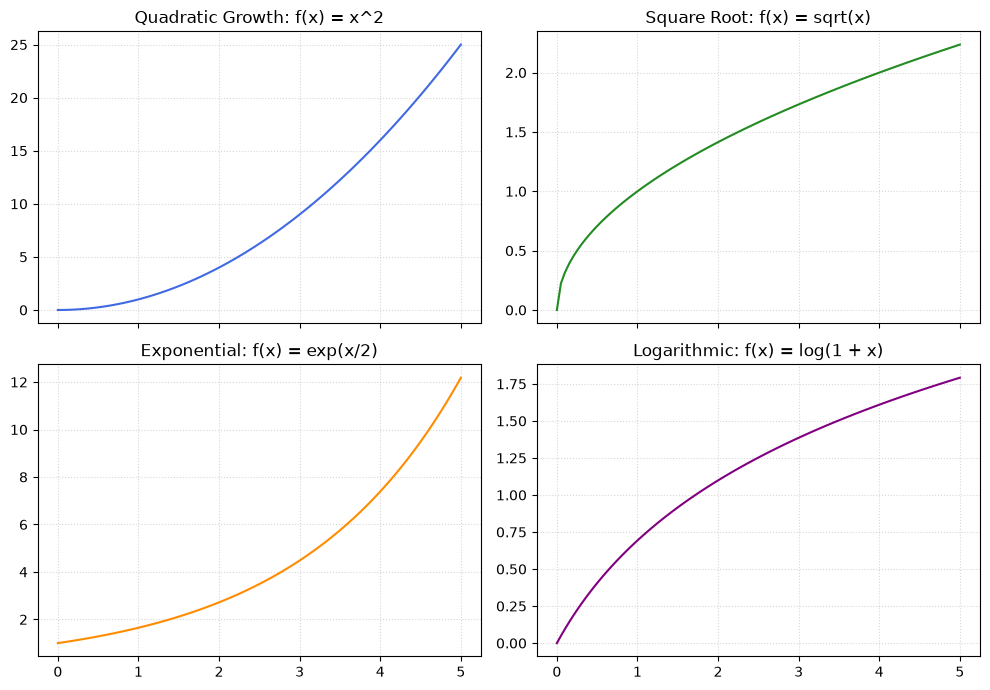

In [2]:
# 2x2 Grid of Subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 7), sharex=True)

x = np.linspace(0, 5, 100)

axes[0, 0].plot(x, x**2, color='royalblue')
axes[0, 0].set_title("Quadratic Growth: f(x) = x^2")

axes[0, 1].plot(x, np.sqrt(x), color='forestgreen')
axes[0, 1].set_title("Square Root: f(x) = sqrt(x)")

axes[1, 0].plot(x, np.exp(x/2), color='darkorange')
axes[1, 0].set_title("Exponential: f(x) = exp(x/2)")

axes[1, 1].plot(x, np.log1p(x), color='purple')
axes[1, 1].set_title("Logarithmic: f(x) = log(1 + x)")

for ax in axes.ravel():
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

---
### 2. Programmatic Subplot Iteration with `.ravel()`

When creating a grid of feature distributions for a dataset with many columns, flattening the 2D array of axes with `axes.ravel()` allows you to iterate using a standard Python `enumerate()` loop!

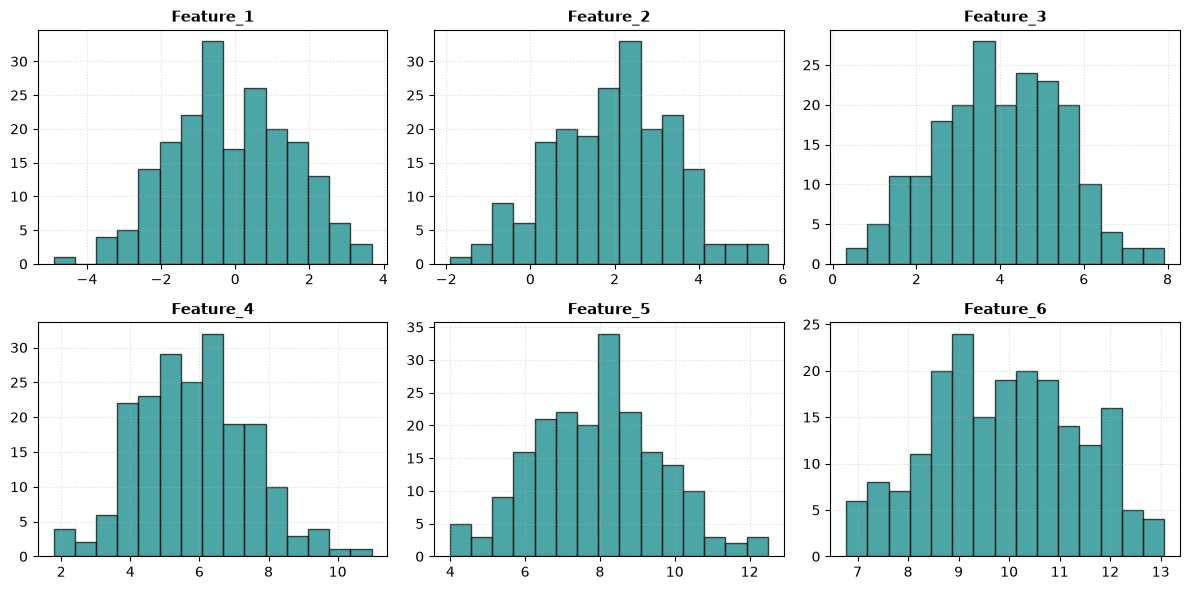

In [3]:
rng = np.random.default_rng(101)
feature_names = ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6']

# 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i, ax in enumerate(axes.ravel()):
    data = rng.normal(loc=i * 2, scale=1.5, size=200)
    ax.hist(data, bins=15, color='teal', edgecolor='black', alpha=0.7)
    ax.set_title(feature_names[i], fontsize=11, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

---
### 3. Asymmetric Layouts with `GridSpec`

In many diagnostic dashboards, you want one primary prominent chart (e.g. training loss covering the entire top row) and smaller secondary plots underneath. `plt.GridSpec` provides full control over row and column spans!

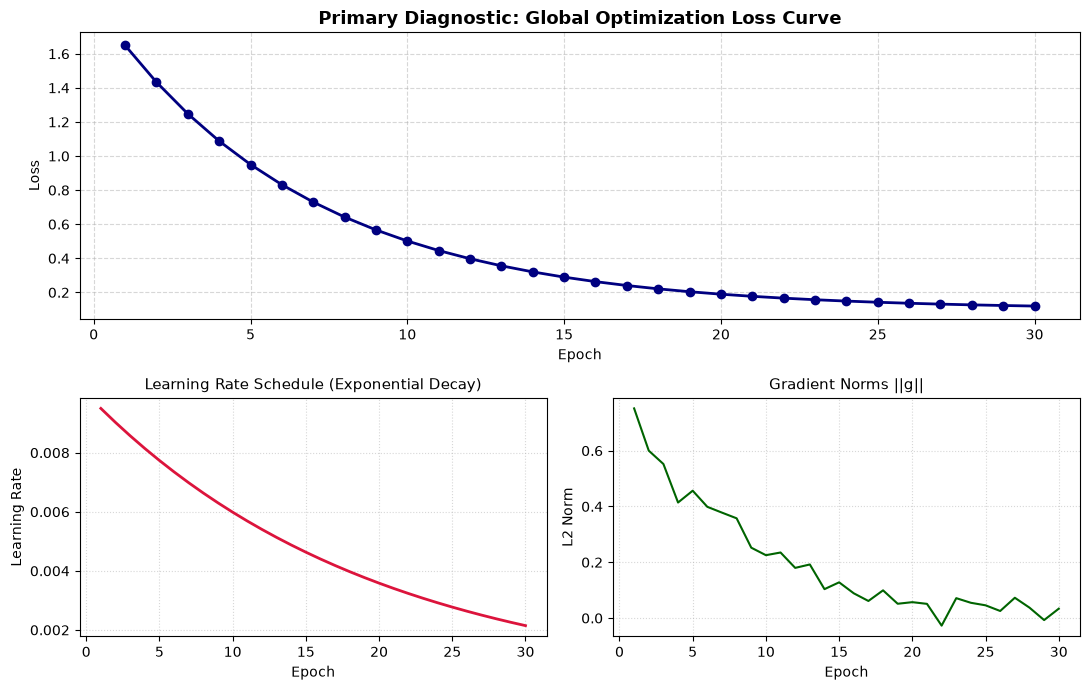

In [4]:
fig = plt.figure(figsize=(11, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

# Large plot spanning the entire top row
ax_top = fig.add_subplot(gs[0, :])

# Two smaller plots on the bottom row
ax_bottom_left = fig.add_subplot(gs[1, 0])
ax_bottom_right = fig.add_subplot(gs[1, 1])

# Plot data
epochs = np.arange(1, 31)
loss = 1.8 * np.exp(-0.15 * epochs) + 0.1
ax_top.plot(epochs, loss, 'o-', color='navy', linewidth=2)
ax_top.set_title("Primary Diagnostic: Global Optimization Loss Curve", fontsize=13, fontweight='bold')
ax_top.set_xlabel("Epoch")
ax_top.set_ylabel("Loss")
ax_top.grid(True, linestyle='--', alpha=0.5)

# Bottom left: Learning rate decay schedule
lr_schedule = 0.01 * (0.95 ** epochs)
ax_bottom_left.plot(epochs, lr_schedule, color='crimson', linewidth=2)
ax_bottom_left.set_title("Learning Rate Schedule (Exponential Decay)", fontsize=11)
ax_bottom_left.set_xlabel("Epoch")
ax_bottom_left.set_ylabel("Learning Rate")
ax_bottom_left.grid(True, linestyle=':', alpha=0.5)

# Bottom right: Gradient Norms
grad_norms = 0.8 * np.exp(-0.12 * epochs) + rng.normal(0, 0.03, size=len(epochs))
ax_bottom_right.plot(epochs, grad_norms, color='darkgreen', linewidth=1.5)
ax_bottom_right.set_title("Gradient Norms ||g||", fontsize=11)
ax_bottom_right.set_xlabel("Epoch")
ax_bottom_right.set_ylabel("L2 Norm")
ax_bottom_right.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Summary & Next Steps
In this notebook, you mastered:
- Subplot grids and axis sharing.
- Programmatic subplot population with `.ravel()`.
- Advanced multi-span layout architecture with `GridSpec`.

**Next Notebook:** `04_advanced_customization_and_ml_visualizations.ipynb` — Twin axes, annotations, decision boundary contouring, ROC curves, and publication-quality exporting.